# Fake News Detector

![](media/bullshit.gif)

![](media/dr_robot_house.png)

Today, you’re stepping into the shoes of a fake news detector. Your mission? Detect fake news like a pro and become the hero the world didn’t know it needed (no cape required).  

Here’s the deal:  
We’ve got a dataset loaded with news articles. Some are real, and some are absolute baloney 🐂💩. Your job is to **clean, standardize, and model the data** to predict whether an article is fake or real. Think of it as training an AI-powered radar to sniff out misinformation. Cool, right?  

### **About the Dataset**  
This isn’t just random internet junk—we’re working with articles collected from real-world sources:  
- **Real News**: Crawled from *Reuters.com*, a trusted news source.  
- **Fake News**: Gathered from unreliable sites flagged by **Politifact** and **Wikipedia**.  

The dataset covers a range of topics, but it leans heavily toward political and world news—areas where fake news thrives.  

### **Dataset Columns**  
Here’s a breakdown of the key information you’ll be working with:  
- **title**: The headline of the article.  
- **text**: The full content of the article.  
- **subject**: The category or topic of the article.  
- **date**: When it was published.  
- **Label**: Whether it’s real (1) or fake (0).  

### **How This Works**  
You’ll be:  
1. **Cleaning up messy text** by removing junk.
2. **Standardizing** the data to make it machine-readable, remove stop words and reducing words to their roots (because "running", "ran", and "runs" are basically the same thing).  
3. **Training a model** to become your official Bullsh*t Detector.  

By the end of this notebook, you’ll have the skills to spot fake news faster than a fact-checker and impress anyone who’s tired of misinformation.  

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Text processing and NLP
import re
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Model building and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Data visualization
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 0. Data

In [2]:
df = pd.read_csv('data/news.csv')
df.head()

,title,text,subject,date,label
0,"Trump’s Own Staff Thinks He’s A Joke, Laughs ...",As the Russian investigation is getting uncomf...,News,"June 12, 2017",0
1,"Kellyanne Conway Just Earned ‘Leaker’ Label, ...",The entire Trump White House is all about crac...,News,"June 10, 2017",0
2,Secret Service Officially Can’t Afford To Pay...,Donald Trump has been wasting taxpayer dollars...,News,"August 21, 2017",0
3,Sicko In Texas Wants To Make A Buck Off Harve...,"Late Monday night, CNN s Don Lemon had a phone...",News,"August 29, 2017",0
4,France’s President Threw AWESOME Shade At Tru...,French President Emmanuel Macron wasted no tim...,News,"June 2, 2017",0


# 1. Exploratory Data Analysis

## 1.1 Cleaning function

Ok the usual lets clean the data

![](media/clean.gif)

In [3]:
def cleaner(text):
    text = re.sub('[.*?]|\w*\d\w*|\n|https?:\\\S+|www\.\S+|<.*?>+', ' ', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\\W', " ", text)
    return text
    

## 1.2 Standardize data
In this section, you are tasked with completing the function standardize_data. Your goal is to process a given text by:

 1. Converting everything to lowercase: Ensures uniformity. 
    
 2. Removing stop words: Filters out common words like "the", "and", or "is" that don't add much meaning. 
    
 3. Applying either stemming or lemmatization: Both are used to reduce words to their base form, but note:  
    - **Stemming** is faster and simpler but may produce non-dictionary roots (e.g., "studies" → "studi").
    
    - **Lemmatization** is more accurate but requires more computational power (e.g., "running" → "run").

 4. Create a new column by applying this to either the title or the text or if you prefer you can concatenate both. call this new column `std_text` 
Below is an example of how you can use stemming, lemmatization, and stop words to process text:




Below is an example of how you can use stemming, lemmatization, and stop words to process text:


In [4]:

import nltk
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
print(stop_words)

{'both', 'after', 'i', 'needn', 'ma', 'about', 'all', 'shouldn', "you'll", 'those', "don't", 'shan', 'being', 'ourselves', 'this', 'down', 'doing', "you'd", "haven't", 'their', 'if', 'of', 'other', 'under', "hasn't", "wouldn't", "weren't", 'haven', 'such', 'yours', 'why', "couldn't", 'he', 'for', 'did', 'then', 'nor', "won't", "it's", 'y', 'more', 'an', 'theirs', 'does', 'too', 'against', "should've", "shouldn't", 'where', 'as', 'whom', "wasn't", 'my', 'through', 'from', 'his', "mustn't", 'won', "she's", 'during', 'them', 'again', 'didn', 'further', 'her', 's', 'over', 'it', 'our', 'themselves', 'in', 'wasn', 'which', "that'll", 'below', 'me', "didn't", 'am', 'is', 'no', 'just', 'couldn', 'or', 'its', 've', 'should', 'on', "aren't", 'there', 'until', "hadn't", 'so', 'do', 'she', 'had', 'ours', 'each', 'been', 'will', 'not', "you're", 'when', 'yourself', 'himself', 'here', 'have', 'the', 'd', 'll', 'hadn', 'yourselves', 'o', 'herself', 're', "needn't", 'we', 'with', 'by', 'off', 'm', 'a

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Utilizador\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
# How does it work

nltk.download("wordnet")
# Initialize SnowballStemmer and WordNetLemmatizer
stemmer = SnowballStemmer("english")
lemmatizer = WordNetLemmatizer()

# Example word
word = "running"

# Apply both stemming and lemmatization
stemmed = stemmer.stem(word)
lemmatized = lemmatizer.lemmatize(word, pos="v")  # 'v' for verb

print(f"Word: {word}")
print(f"Stemmed: {stemmed}")
print(f"Lemmatized: {lemmatized}")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Utilizador\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Word: running
Stemmed: run
Lemmatized: run


In [6]:
nltk.download("punkt_tab")
# Sentence to analyze
sentence = "Studies show that the happiest people normally like running"

# Tokenize the sentence
words = word_tokenize(sentence)
# print(words)


# Apply both stemming and lemmatization
stemmed_words = [stemmer.stem(word) for word in words]
lemmatized_words = [lemmatizer.lemmatize(word.lower(), pos="v") for word in words]

# Display the results
print("Original words:", words)
print("Stemmed words:", stemmed_words)
print("Lemmatized words:", lemmatized_words)

Original words: ['Studies', 'show', 'that', 'the', 'happiest', 'people', 'normally', 'like', 'running']
Stemmed words: ['studi', 'show', 'that', 'the', 'happiest', 'peopl', 'normal', 'like', 'run']
Lemmatized words: ['study', 'show', 'that', 'the', 'happiest', 'people', 'normally', 'like', 'run']


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Utilizador\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


#### Your Task
 - Complete the function standardize_data to process a list of sentences.
 - Decide whether to use stemming or lemmatization based on your preference or system performance constraints.
 - Use the provided example as a reference for handling tokenization, stop words, and standardization.

#### Hint
Remember:
- Use `word_tokenize` for splitting sentences into tokens.  
  
- Use the `stopwords.words("english")` from `nltk` to filter out stop words.

In [7]:

def standardize_data(sentence,stopwords = stopwords.words("english")):
    
    sentence = sentence.lower()
    words = word_tokenize(sentence)
    new_words = [word for word in words if not word in stopwords]
    lemmatized_words = [lemmatizer.lemmatize(word.lower(), pos="v") for word in new_words]
    #convert lower case
    #tokenize
    #remove stop words
    #standardize words using stemming or lematization

    # join all the treated tokens again 
    return ' '.join(lemmatized_words) 

standardize_data("My name is Bernardo and I'm a green fridge", stopwords.words("english"))

"name bernardo 'm green fridge"

In [8]:
corpus = pd.read_csv("./data/news.csv")
a = corpus["text"].str.cat(sep = " ")
print(a[:100])


As the Russian investigation is getting uncomfortably close to home for Donald Trump and as his insi


In [9]:
corpus.head(10)


,title,text,subject,date,label
0,"Trump’s Own Staff Thinks He’s A Joke, Laughs ...",As the Russian investigation is getting uncomf...,News,"June 12, 2017",0
1,"Kellyanne Conway Just Earned ‘Leaker’ Label, ...",The entire Trump White House is all about crac...,News,"June 10, 2017",0
2,Secret Service Officially Can’t Afford To Pay...,Donald Trump has been wasting taxpayer dollars...,News,"August 21, 2017",0
3,Sicko In Texas Wants To Make A Buck Off Harve...,"Late Monday night, CNN s Don Lemon had a phone...",News,"August 29, 2017",0
4,France’s President Threw AWESOME Shade At Tru...,French President Emmanuel Macron wasted no tim...,News,"June 2, 2017",0
5,Kremlin says Putin not influenced by ex-Trump ...,MOSCOW (Reuters) - The Kremlin said on Monday ...,politicsNews,"December 4, 2017",1
6,"Manafort, ex-associate face charges in U.S. Ru...",WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"October 30, 2017",1
7,Obama’s Head Of Disaster Relief TRASHES Trump...,It s no secret that Donald Trump s response to...,News,"September 30, 2017",0
8,Iowa pulls request to opt out of Obamacare req...,(Reuters) - Iowa on Monday withdrew a request ...,politicsNews,"October 24, 2017",1
9,U.S. says holds Myanmar military leaders accou...,WASHINGTON (Reuters) - U.S. Secretary of State...,politicsNews,"October 18, 2017",1


## 1.3 Word Clouds

to create a word cloud concatenate all the texts into a very long string and then let the `WordCloud` deal with the rest

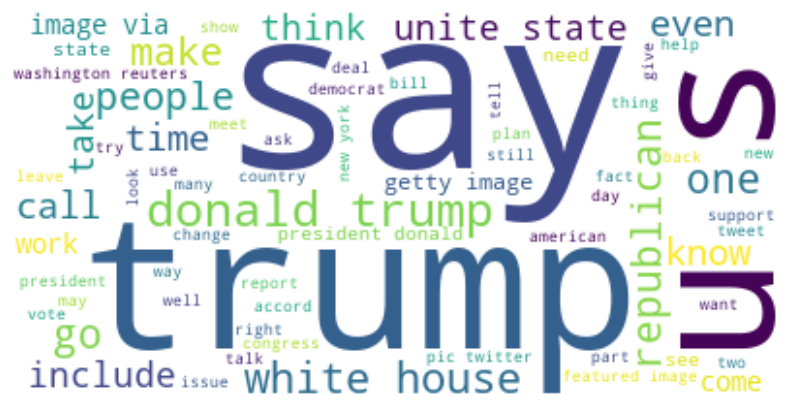

In [10]:
# corpus = df['text'].apply(lambda x:cleaner(x, stopwords))
data = pd.read_csv("./data/news.csv")
# data["std_text"] = data["text"].apply(lambda x: standardize_data(x))
data["std_text"] = data["text"].apply(lambda x: standardize_data(x))
corpus = data["std_text"].str.cat(sep = " ")
a_long_sentence = standardize_data(corpus)
wc = WordCloud(background_color='white', max_words=70)#,colormap='gist_gray')                  # Customize the output.
wc.generate(a_long_sentence)
# wc.words_                                                          # Check for the top ranking words.                                                         
plt.figure(figsize=(10,10))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")                                    # Turn off the axes.
plt.show()

In [11]:
#using the code above create one word cloud for Label 0 and label 1
data

,title,text,subject,date,label,std_text
0,"Trump’s Own Staff Thinks He’s A Joke, Laughs ...",As the Russian investigation is getting uncomf...,News,"June 12, 2017",0,russian investigation get uncomfortably close ...
1,"Kellyanne Conway Just Earned ‘Leaker’ Label, ...",The entire Trump White House is all about crac...,News,"June 10, 2017",0,entire trump white house crack leak make look ...
2,Secret Service Officially Can’t Afford To Pay...,Donald Trump has been wasting taxpayer dollars...,News,"August 21, 2017",0,donald trump waste taxpayer dollars personal v...
3,Sicko In Texas Wants To Make A Buck Off Harve...,"Late Monday night, CNN s Don Lemon had a phone...",News,"August 29, 2017",0,"late monday night , cnn lemon phone guest call..."
4,France’s President Threw AWESOME Shade At Tru...,French President Emmanuel Macron wasted no tim...,News,"June 2, 2017",0,french president emmanuel macron waste time co...
...,...,...,...,...,...,...
2995,"Just Back From A Golfing Vacay, Trump Says He...",Donald Trump just got back from binge-golfing ...,News,"November 26, 2017",0,donald trump get back binge-golfing span five ...
2996,"Democrats to join Trump, Republicans in talks ...",WASHINGTON (Reuters) - Democratic leaders in C...,politicsNews,"December 4, 2017",1,washington ( reuters ) - democratic leaders co...
2997,House Speaker Ryan mulls retirement after 2018...,WASHINGTON (Reuters) - Republican House Speake...,politicsNews,"December 14, 2017",1,washington ( reuters ) - republican house spea...
2998,Doubts linger after Florida's Scott pitches bi...,NEW YORK (Reuters) - After deep cuts in spendi...,politicsNews,"November 21, 2017",1,new york ( reuters ) - deep cut spend florida ...


## 1.4 Create more features ( Optional )
This is an optional part if you have time you can added to the documents and analysis simple features like lenght of the title, text, average length of each word...

# 2. Vectorize using tf-idf

Using tf-idf vectorizer compare the amount of generate variables with `std_text` and the original variable `text`. To do this use `len(tfidf.get_feature_names_out())`

In [12]:

tfidf = TfidfVectorizer()
tfidf.fit(data["std_text"])
len(tfidf.get_feature_names_out())

28333

# 3. Vectorize and Model it 
![](media/predict.jpeg)

In [13]:
# Define X

# Create the TfidfVectorizer
tfidf = TfidfVectorizer(max_features = 500000)
X = tfidf.fit_transform(data["std_text"])
X_ = X.toarray()  
y = df['label']  # Target variable


# normX = tfidf.fit_transform(data["text"].apply(standardize_data))
# nomrX_ = normX.toarray()

In [14]:
# For the first try ignore this cell Now if you want you can convert this into a dataframe and add more variables. 

## Get the feature names (words) from the TfidfVectorizer
# words = tfidf.get_feature_names_out()
## Convert the TF-IDF matrix (X_) to a DataFrame
# X_df = pd.DataFrame(X_, columns=words)

In [15]:
data["text"][:100]

0     As the Russian investigation is getting uncomf...
1     The entire Trump White House is all about crac...
2     Donald Trump has been wasting taxpayer dollars...
3     Late Monday night, CNN s Don Lemon had a phone...
4     French President Emmanuel Macron wasted no tim...
                            ...                        
95    No one likes to be touched by Donald Trump   n...
96    It s an epidemic over there inside the Fox net...
97    The legal mind behind the Bush Administration ...
98    WASHINGTON (Reuters) - Republican leaders in t...
99    As more time passes after the violent riots re...
Name: text, Length: 100, dtype: object

In [16]:
# Prepare training dataset and create the model
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X_, y, test_size=0.20, random_state=42)

# Initialize and train the Logistic Regression model
model = LogisticRegression()

In [17]:
# fit the model using .fit method
model.fit(X_train, y_train)

# Make predictions using .predict
y_pred= model.predict(X_test)




# Evaluate the model
![](media/eval.gif)

accuracy is 98.667 %


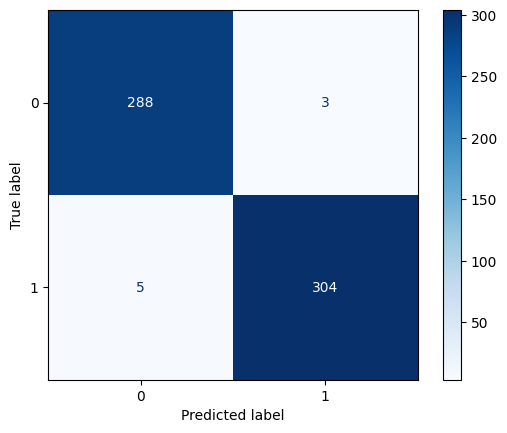

In [18]:
### Evaluation Calculating metrics 

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy is {np.round(accuracy*100,3)} %")


#  Calculate and display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')  